<a href="https://colab.research.google.com/github/lilian0703/stat-6209-topic-3-project/blob/main/LoRAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Install the environment

In [2]:
!nvidia-smi
!pip install --upgrade protobuf==5.29.1
!pip install numpy==1.26.0
!pip install wandb==0.16.3
!pip install --upgrade accelerate diffusers[training]
!pip install -q transformers datasets peft bitsandbytes xformers huggingface_hub

Thu Mar 19 10:15:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 97.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
music21 9.9.1 requires numpy>=1.26.4, but you have numpy 1.26.0 which is incompatible.
shap 0.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 37.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.1
    Uninstalling protobuf-5.29.1:
      Successfully uninstalled protobuf-5.29.1
  Attempting uninstall: wandb
    Found existing installation: wandb 0.25.1
    Uninstalling wandb-0.25.1:
      Successfully uninstalled wandb-0.25.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.8
    Uninstalling protobuf-4.25.8:
      Successfully uninstalled protobuf-4.25.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
google-api-core 2.30.0 requires protobuf<7.0.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 96.5 MB/s eta 0:00:00


# Step 2: Upload and check the training data

In [1]:
import os
image_dir = "/content/sticker_images"
os.makedirs(image_dir, exist_ok=True)

In [3]:
images = os.listdir(image_dir)
print(f"find {len(images)} picturs：{images[:]}")
if len(images) == 0:
    raise Exception("upload /content/sticker_images first！")

find 5 picturs：['cartoon_elephant.png', 'cartoon_cat.png', 'cartoon_fox.png', 'cartoon_pandas.png', 'cartoon_dog.png']


# Step 3: Diffusers

In [4]:
import os
os.environ["WANDB_DISABLED"] = "true"
!git clone https://github.com/huggingface/diffusers.git
%cd /content/diffusers

Cloning into 'diffusers'...
remote: Enumerating objects: 118601, done.
remote: Counting objects: 100% (524/524), done.
remote: Compressing objects: 100% (273/273), done.
remote: Total 118601 (delta 445), reused 251 (delta 251), pack-reused 118077 (from 5)
Receiving objects: 100% (118601/118601), 91.66 MiB | 30.99 MiB/s, done.
Resolving deltas: 100% (88577/88577), done.
/content/diffusers


# Step 4: Training Lora

In [5]:
# clean the history
!rm -rf /content/lora_sticker_model

# confirm the parameters
!python examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="/content/sticker_images" \
  --output_dir="/content/lora_sticker_model" \
  --instance_prompt="a sticker in <sticker-style> style" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --mixed_precision="fp16" \
  --use_8bit_adam

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Traceback (most recent call last):
  File "/content/diffusers/examples/dreambooth/train_dreambooth_lora.py", line 78, in <module>
    check_min_version("0.38.0.dev0")
  File "/usr/local/lib/python3.12/dist-packages/diffusers/utils/__init__.py", line 171, in check_min_version
    raise ImportError(error_message)
ImportError: This example requires a source install from HuggingFace diffusers (see `https://huggingface.co/docs/diffusers/installation#install-from-source`), but the version found is 0.37.0.



In [6]:
%cd /content/diffusers
!pip install -e ".[torch]"
import diffusers

/content/diffusers
Obtaining file:///content/diffusers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for diffusers (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0-0.editable-py3-none-any.whl size=11388 sha256=b17c1cc021fd3289efa4c652cef5625a74c883140a25064b50db6a2b688ba5a5
  Stored in directory: /tmp/pip-ephem-wheel-cache-wlar5ncj/wheels/8a/fc/09/385efb77b455b2fd4a656c950079c93147e1f50ae614e51beb
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.0
    Uninstalling diffusers-0.37.0:
      Successfully uninstalled diffusers-0.37.0


AttributeError: module 'diffusers' has no attribute '__version__'

In [7]:
%cd /content/diffusers
!python examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="/content/sticker_images" \
  --output_dir="/content/lora_sticker_model" \
  --instance_prompt="a sticker in <sticker-style> style" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --mixed_precision="fp16" \
  --use_8bit_adam

/content/diffusers
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
tokenizer_config.json: 100% 806/806 [00:00<00:00, 4.84MB/s]
vocab.json: 1.06MB [00:00, 62.6MB/s]
merges.txt: 525kB [00:00, 117MB/s]
special_tokens_map.json: 100% 472/472 [00:00<00:00, 3.09MB/s]
config.json: 100% 617/617 [00:00<00:00, 3.52MB/s]
You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
scheduler_config.json

In [9]:
import os
model_dir = "/content/lora_sticker_model"
print("exist?", os.path.exists(model_dir))

exist? True


# Step 5: Testing

In [11]:
!pip uninstall -y diffusers
!pip install diffusers[torch] --upgrade

Found existing installation: diffusers 0.38.0.dev0
Uninstalling diffusers-0.38.0.dev0:
  Successfully uninstalled diffusers-0.38.0.dev0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 70.1 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/diffusers/loaders/unet.py:214: FutureWarning: `load_attn_procs` is deprecated and will be removed in version 0.40.0. Using the `load_attn_procs()` method has been deprecated and will be removed in a future version. Please use `load_lora_adapter()`.
  deprecate("load_attn_procs", "0.40.0", deprecation_message)


  0%|          | 0/50 [00:00<?, ?it/s]

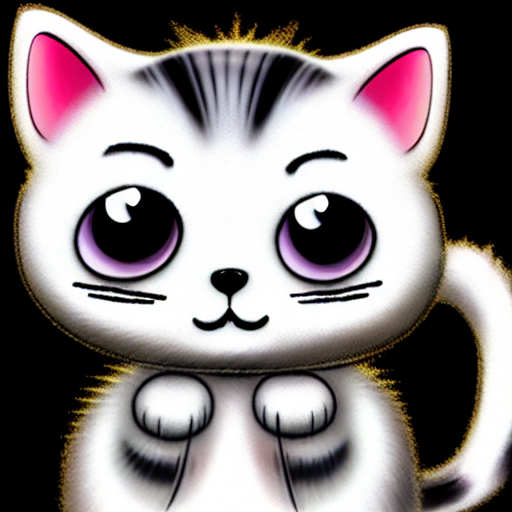

In [1]:
from diffusers import StableDiffusionPipeline
import torch
# loading models
pipe=StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")
pipe.unet.load_attn_procs("/content/lora_sticker_model")

# generating pictures
prompt="a cute cat, <sticker-style> style, vibrant colors, sticker design, white background"
image=pipe(prompt, num_inference_steps=50).images[0]
image

# Step 6: Save the model to the Hugging face

In [24]:
import os
model_dir = "/content/lora_sticker_model"
print("exsit？", os.path.exists(model_dir))
if os.path.exists(model_dir):
    print("list：", os.listdir(model_dir))

exsit？ True
list： ['checkpoint-500', 'logs', 'adapter_config.json', 'pytorch_lora_weights.safetensors']


In [18]:
!find /content -name "*.json" 2>/dev/null
!find /content -name "*.safetensors" 2>/dev/null

/content/.config/.last_update_check.json
/content/sample_data/anscombe.json
/content/lora_sticker_model/checkpoint-500/pytorch_lora_weights.safetensors
/content/lora_sticker_model/pytorch_lora_weights.safetensors


In [20]:
import json
import os

model_dir = "/content/lora_sticker_model"
config = {
    "base_model_name_or_path": "runwayml/stable-diffusion-v1-5",
    "revision": None,
    "rank": 8,
    "alpha": 16,
    "dropout": 0.1,
    "target_modules": ["to_q", "to_k", "to_v", "to_out.0"]
}
with open(os.path.join(model_dir, "adapter_config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("adapter_config.json existed", model_dir)

adapter_config.json existed /content/lora_sticker_model


In [21]:
from google.colab import files

files.download(os.path.join(model_dir, "pytorch_lora_weights.safetensors"))
files.download(os.path.join(model_dir, "adapter_config.json"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

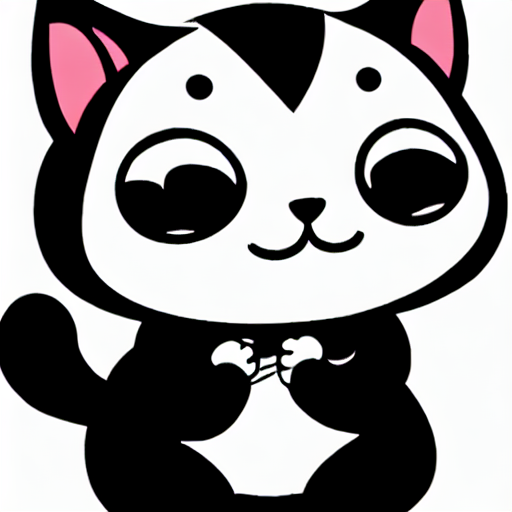

In [25]:
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to("cuda")
pipe.unet.load_attn_procs("Lilian0703/sticker-lora-cartoon")
image = pipe("a cute cat, <sticker-style> style").images[0]
image